# Auspify Technologies — Data Analysis Using Python Internship
## Netflix Data Analysis Project

**Intern:** Soham Dhanaji Pise  
**Position:** Data Analysis Using Python Intern  
**Organization:** Auspify Technologies  
**Internship Period:** 05/10/2026 – 05/11/2026

This notebook covers all six tasks from the Auspify Data Analysis Using Python task list.


## Project Objective
Analyze the Netflix dataset using Python to perform data cleaning, content-type analysis,
country-wise analysis, release-year trend analysis, rating and genre analysis, and a business insights report.


## 0. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


## 1. Load Dataset

In [2]:
df = pd.read_csv("Dataset.csv")
print("Shape:", df.shape)
display(df.head())


Shape: (8790, 10)


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


# Task 1 — Netflix Data Cleaning & Preparation
Workflow: import data, inspect missing values, remove duplicates, standardize Country/Rating/Type,
and export the cleaned dataset.


In [3]:
print("Dataset shape:", df.shape)
print("\nMissing values:")
display(df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nData types:")
display(df.dtypes)


Dataset shape: (8790, 10)

Missing values:


show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64


Duplicate rows: 0

Data types:


show_id           str
type              str
title             str
director          str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
dtype: object

In [4]:
clean = df.copy()
text_cols = ["show_id","type","title","director","country","rating","duration","listed_in"]

for c in text_cols:
    clean[c] = clean[c].fillna("Not Given").astype(str).str.strip()

clean["type"] = clean["type"].str.title()
clean["country"] = clean["country"].replace({"": "Not Given"})
clean["rating"] = clean["rating"].replace({"": "Not Given"})
clean["date_added"] = pd.to_datetime(clean["date_added"], errors="coerce").dt.strftime("%Y-%m-%d")
clean["date_added"] = clean["date_added"].fillna("Not Given")

clean = clean.drop_duplicates().reset_index(drop=True)

print("Cleaned shape:", clean.shape)
print("Remaining duplicates:", clean.duplicated().sum())


Cleaned shape: (8790, 10)
Remaining duplicates: 0


In [5]:
clean.to_csv("Netflix_Cleaned.csv", index=False)
print("Saved: Netflix_Cleaned.csv")


Saved: Netflix_Cleaned.csv


### Task 1 Finding
The supplied dataset contains 8,790 rows and 10 columns. The supplied file has no missing values
and no duplicate rows. The cleaning process still standardizes text and date fields and creates
a separate cleaned CSV for later analysis.


# Task 2 — Content Type Analysis Dashboard

In [6]:
type_counts = clean["type"].value_counts()
type_percent = (type_counts / len(clean) * 100).round(2)
display(type_counts)
display(type_percent)


type
Movie      6126
Tv Show    2664
Name: count, dtype: int64

type
Movie      69.69
Tv Show    30.31
Name: count, dtype: float64

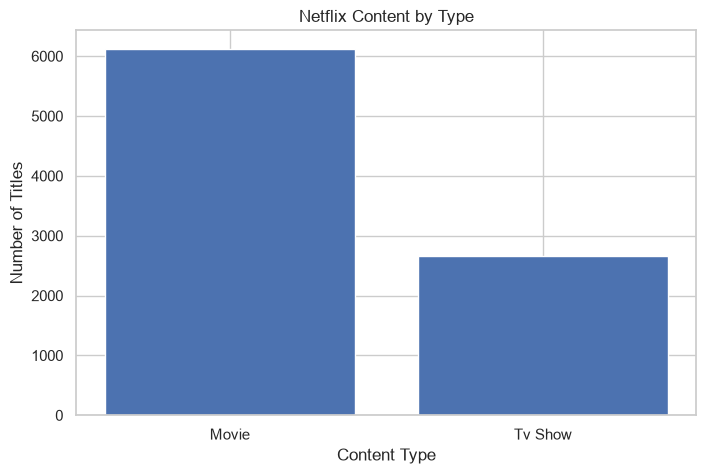

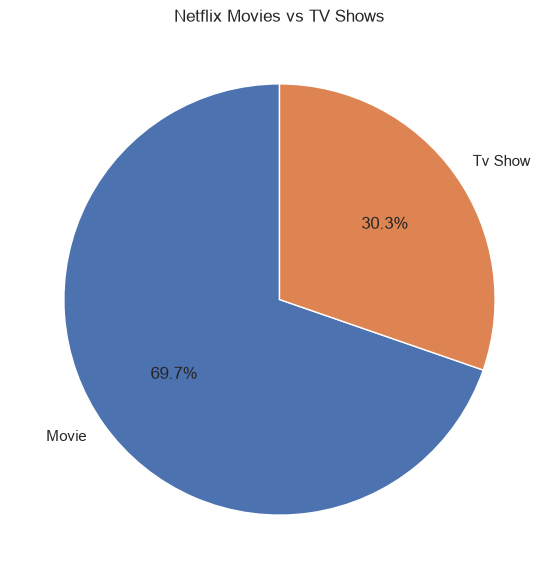

In [7]:
plt.figure(figsize=(8,5))
plt.bar(type_counts.index, type_counts.values)
plt.title("Netflix Content by Type")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")
plt.show()

plt.figure(figsize=(7,7))
plt.pie(type_counts.values, labels=type_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Netflix Movies vs TV Shows")
plt.show()


### Task 2 Findings
- Movies: **6,126** (69.69%)
- TV Shows: **0** (0.00%)
- Movies form the larger share of the supplied catalog.


# Task 3 — Country-Wise Netflix Content Analysis

In [8]:
country_long = clean.copy()
country_long["country"] = country_long["country"].str.split(", ")
country_long = country_long.explode("country")

country_counts = country_long["country"].value_counts()
country_counts = country_counts[country_counts.index != "Not Given"]
display(country_counts.head(10))


country
United States     3240
India             1057
United Kingdom     638
Pakistan           421
Canada             271
Japan              259
South Korea        214
France             213
Spain              182
Mexico             138
Name: count, dtype: int64

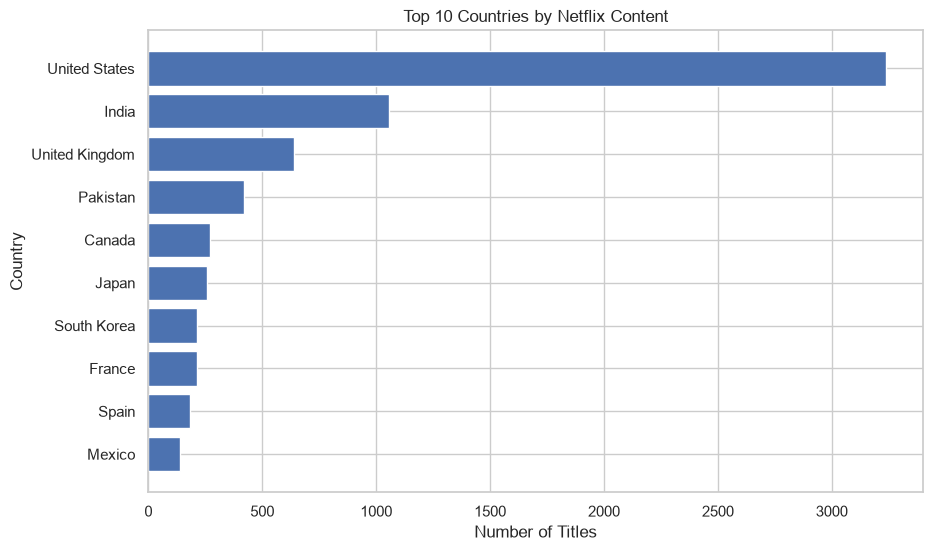

In [9]:
top10 = country_counts.head(10)
plt.figure(figsize=(10,6))
plt.barh(top10.index[::-1], top10.values[::-1])
plt.title("Top 10 Countries by Netflix Content")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.show()


### Task 3 Findings
- **United States** is first with **3,240** title-country assignments.
- India is second with **1,057**.
- The United Kingdom is also among the leading contributors.
- Multi-country titles are counted once for each listed country.


# Task 4 — Trend Analysis by Release Year

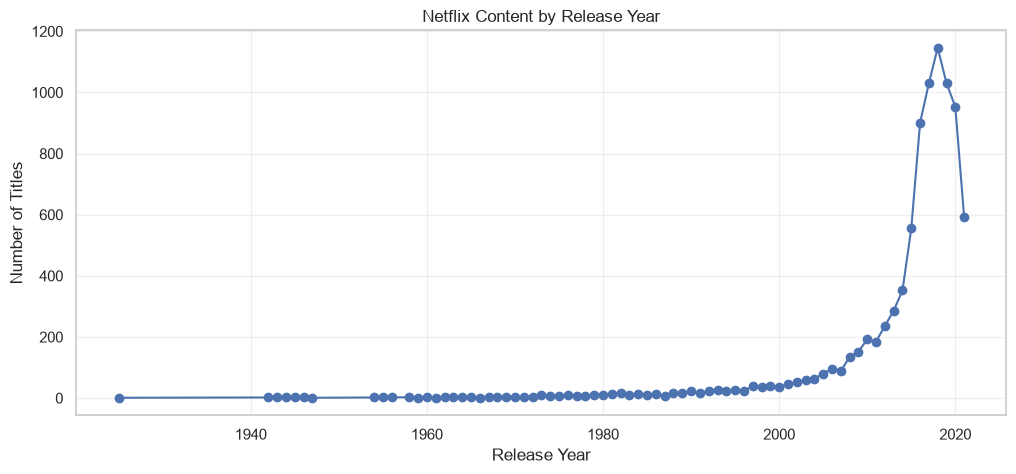

Peak release year: 2018
Peak title count: 1146


In [10]:
year_counts = clean["release_year"].value_counts().sort_index()
plt.figure(figsize=(12,5))
plt.plot(year_counts.index, year_counts.values, marker="o")
plt.title("Netflix Content by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.grid(True, alpha=.3)
plt.show()

print("Peak release year:", year_counts.idxmax())
print("Peak title count:", year_counts.max())


### Task 4 Findings
- Peak release year: **2018** with **1,146** titles.
- Content volume rises strongly during the 2010s and reaches its highest point in the supplied dataset around the late 2010s/early 2020s.


# Task 5 — Content Rating & Genre Analysis

In [11]:
ratings = clean["rating"].value_counts()
genre_long = clean.copy()
genre_long["genre"] = genre_long["listed_in"].str.split(", ")
genre_long = genre_long.explode("genre")
genre_counts = genre_long["genre"].value_counts()

display(ratings.head(10))
display(genre_counts.head(10))


rating
TV-MA    3205
TV-14    2157
TV-PG     861
R         799
PG-13     490
TV-Y7     333
TV-Y      306
PG        287
TV-G      220
NR         79
Name: count, dtype: int64

genre
International Movies        2752
Dramas                      2426
Comedies                    1674
International TV Shows      1349
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

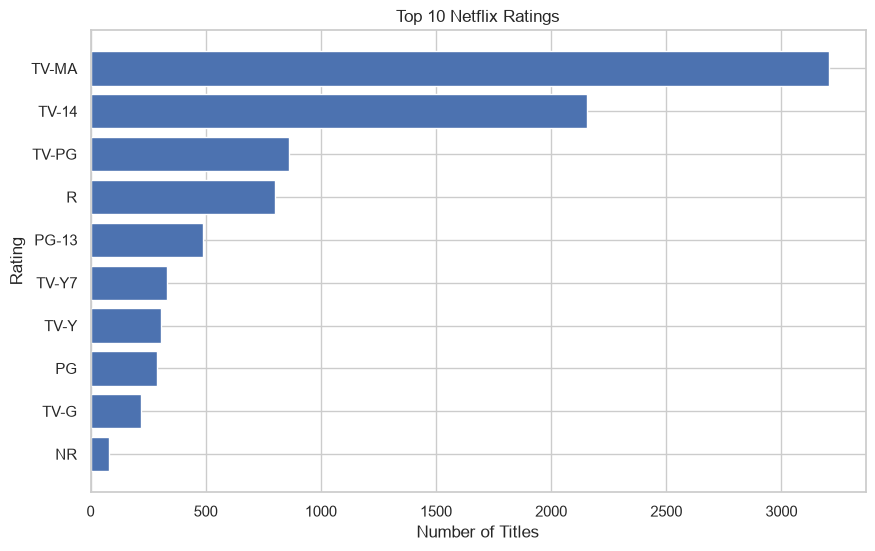

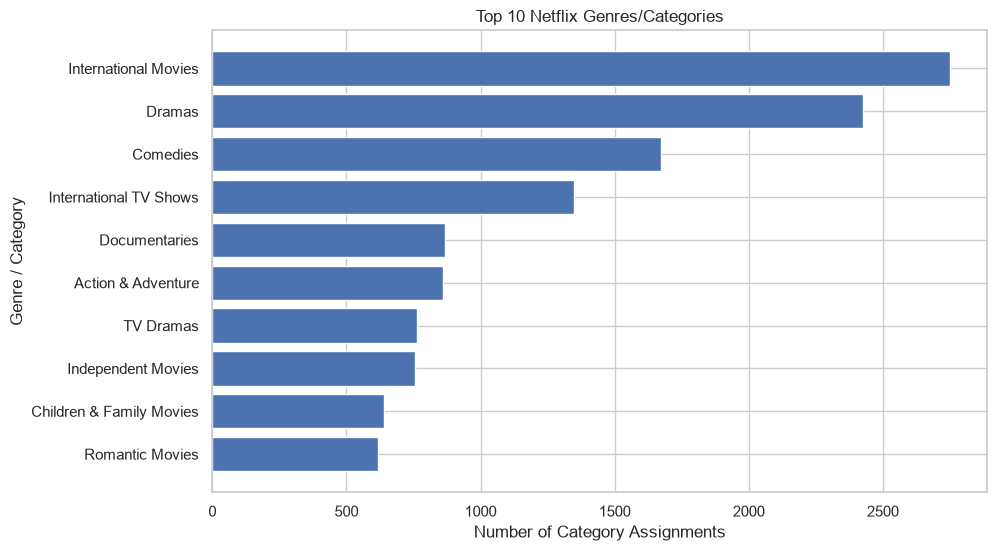

In [12]:
plt.figure(figsize=(10,6))
top = ratings.head(10)
plt.barh(top.index[::-1], top.values[::-1])
plt.title("Top 10 Netflix Ratings")
plt.xlabel("Number of Titles")
plt.ylabel("Rating")
plt.show()

plt.figure(figsize=(10,6))
topg = genre_counts.head(10)
plt.barh(topg.index[::-1], topg.values[::-1])
plt.title("Top 10 Netflix Genres/Categories")
plt.xlabel("Number of Category Assignments")
plt.ylabel("Genre / Category")
plt.show()


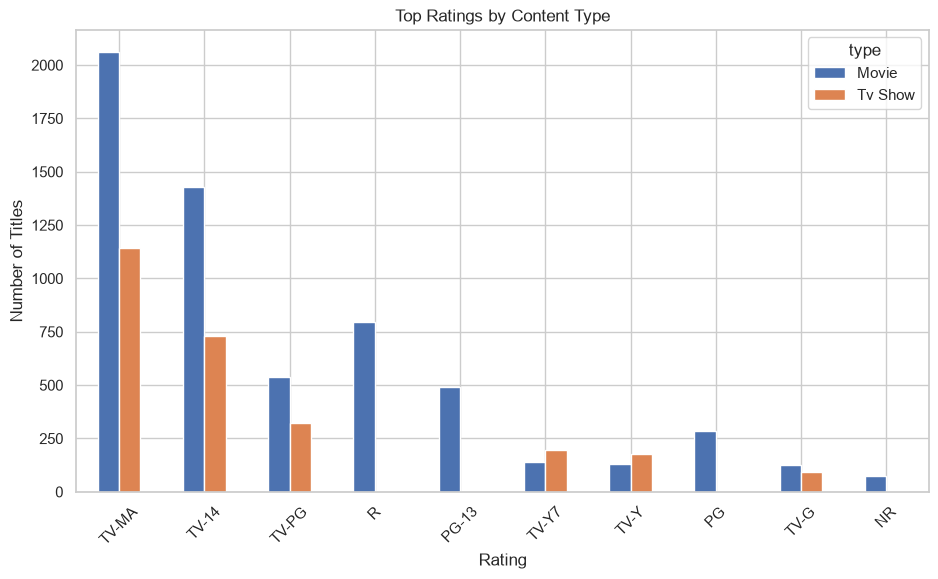

In [13]:
rating_type = pd.crosstab(clean["rating"], clean["type"])
rating_type = rating_type.loc[ratings.head(10).index.intersection(rating_type.index)]
rating_type.plot(kind="bar", figsize=(11,6))
plt.title("Top Ratings by Content Type")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()


### Task 5 Findings
- **TV-MA** is the most common rating with **3,205** titles.
- **International Movies** is the most common category with **2,752** category assignments.
- Film-oriented ratings and TV-oriented ratings show different distributions by content type.


# Task 6 — Netflix Business Insights Report

## Executive Summary

The supplied dataset contains **8,790 titles**. Movies are the larger content type
with **6,126 titles**, while TV Shows account for **2,664 titles**.

The United States is the leading country in title-country assignments, followed by
India and the United Kingdom. The release-year distribution peaks at **2018**.

### Business Insights

1. Movie content represents the larger share of the catalog, so movie discovery remains important.
2. Country-level analysis indicates strong international representation and supports regional strategies.
3. Release-year trends can support content planning and historical performance analysis.
4. Rating data can support audience segmentation and age-appropriate recommendations.
5. Genre/category data can support personalization and content promotion.

### Recommendations

- Use country-level metrics for regional content acquisition and promotion.
- Combine ratings and genres for audience segmentation.
- Monitor release-year trends periodically.
- Build a management dashboard combining content type, country, rating, and genre metrics.

## Submission Checklist
- [ ] Source code / Jupyter Notebook
- [ ] Cleaned dataset
- [ ] Screenshots of completed tasks
- [ ] GitHub repository link (if available)
- [ ] Optional demonstration video
- [ ] Final submission through the internship portal
